# CNN Heavy Mel-Spectrogram
This notebook downloads and processes only the heavy mel-spectrogram dataset.

## Colab Runtime Setup
Local imports work in Colab only if `common_utils.py` and `cnn_utils.py` are present in the remote runtime. If you use the VS Code Colab extension, make sure both files are synced, uploaded, mounted from Drive, or downloaded before imports run.

In [1]:
import sys
from pathlib import Path

UTILS_GITHUB_RAW_BASE_URL = "https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main/utils"
UTILITY_FILES = ("common_utils.py",)

candidate_dirs = [
    Path.cwd() / "utils",
    Path.cwd().parent / "utils",
    Path("/content/utils"),
    Path("/content/drive/MyDrive/STUDA/src/utils"),
]

utilities_dir = next(
    (directory for directory in candidate_dirs if all((directory / filename).exists() for filename in UTILITY_FILES)),
    None,
)

if utilities_dir is None and UTILS_GITHUB_RAW_BASE_URL:
    import urllib.request
    utilities_dir = Path("/content")
    for filename in UTILITY_FILES:
        urllib.request.urlretrieve(f"{UTILS_GITHUB_RAW_BASE_URL}/{filename}", utilities_dir / filename)
    model_dir = Path("/content/CNN")
    model_dir.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve("https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main/CNN/cnn_utils.py", model_dir / "cnn_utils.py")

if utilities_dir is None or not all((utilities_dir / filename).exists() for filename in UTILITY_FILES):
    raise FileNotFoundError(
        f"{UTILITY_FILES} were not found in the Colab runtime. "
        "Sync them with the VS Code Colab extension, upload them to /content, mount Drive, "
        "or set UTILS_GITHUB_RAW_BASE_URL before importing."
    )

sys.path.insert(0, str(utilities_dir))
model_dirs = [Path.cwd(), Path.cwd() / "CNN", Path.cwd().parent / "CNN", Path("/content/CNN"), Path("/content/drive/MyDrive/STUDA/src/CNN")]
model_dir = next((directory for directory in model_dirs if (directory / "cnn_utils.py").exists()), None)
if model_dir is None:
    raise FileNotFoundError("cnn_utils.py was not found.")
sys.path.insert(0, str(model_dir))
print(f"Using utility modules from: {utilities_dir}")


Using pipeline module: /content/spectrogram_pipeline.py


In [2]:
from IPython.display import display
from google.colab import files, userdata

from common_utils import evaluate_models_for_variants, extract_zip, plot_training_histories, prepare_dataset_variants, save_keras_artifacts, train_keras_models_for_variants, zip_artifacts
from cnn_utils import build_cnn_models_for_variants, get_cnn_callbacks


## Dataset Download

In [ ]:
DATASET_KEY = "heavy"
DATASET_LABEL = "Mel-Spectrogram Heavy"
DATASET_SLUG = "pawedyrda/mel-spectrogram-heavy"
ARCHIVE_PATH = Path("/content/mel-spectrogram-heavy.zip")
DATA_PATH = Path("/content/mel-spectrogram-heavy")
EPOCHS = 50
BATCH_SIZE = 32


In [4]:
kaggle_token = "KGAT_13e99a89ce99374acab577737d175634"

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)
token_path = kaggle_dir / "access_token"
token_path.write_text(kaggle_token)
token_path.chmod(0o600)


In [5]:
!kaggle datasets download -d {DATASET_SLUG} -p /content --force
DATA_PATH = extract_zip(ARCHIVE_PATH, "/content")
print(f"Dataset extracted to: {DATA_PATH}")


Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mel-spectrogram-heavy
License(s): unknown
100% 9.54G/9.54G [07:37<00:00, 22.4MB/s]  

Dataset extracted to: /content/mel_spectrograms_heavy


## Prepare Normal, M, And W Variants

In [6]:
variants = prepare_dataset_variants(DATA_PATH)
print("Normal train shape:", variants.normal.train_data.shape)
print("M train shape:", variants.m.train_data.shape)
print("W train shape:", variants.w.train_data.shape)


Scanning spectrogram data in: /content/mel_spectrograms_heavy
Found .npz files: 9674, skipped: 0
Loaded samples: 9674
X shape: (9674, 1236, 256)
y shape: (9674, 17)
Scanning spectrogram data in: /content/mel_spectrograms_heavy (UUV filter: M)
Found .npz files: 9674, skipped: 523
Loaded samples: 9151
X shape: (9151, 1236, 256)
y shape: (9151, 17)
Scanning spectrogram data in: /content/mel_spectrograms_heavy (UUV filter: W)
Found .npz files: 9674, skipped: 379
Loaded samples: 9295
X shape: (9295, 1236, 256)
y shape: (9295, 17)
Normal train shape: (6191, 1236, 256, 1)
M train shape: (5856, 1236, 256, 1)
W train shape: (5948, 1236, 256, 1)


## Multilabel CNNs

In [7]:
multilabel_models = build_cnn_models_for_variants(variants, model_type="multilabel")
multilabel_histories = train_keras_models_for_variants(
    multilabel_models,
    variants,
    model_type="multilabel",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callback_factory=get_cnn_callbacks,
)


Training multilabel model for variant: normal
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 64s 193ms/step - binary_accuracy: 0.9051 - loss: 0.2542 - pr_auc: 0.2976 - precision: 0.3961 - recall: 0.2100 - roc_auc: 0.7927 - val_binary_accuracy: 0.8937 - val_loss: 0.3194 - val_pr_auc: 0.1495 - val_precision: 0.1314 - val_recall: 0.0419 - val_roc_auc: 0.7284 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - binary_accuracy: 0.9161 - loss: 0.2251 - pr_auc: 0.3752 - precision: 0.5243 - recall: 0.2027 - roc_auc: 0.8350 - val_binary_accuracy: 0.9140 - val_loss: 0.2603 - val_pr_auc: 0.2646 - val_precision: 0.5263 - val_recall: 0.0088 - val_roc_auc: 0.7934 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - binary_accuracy: 0.9172 - loss: 0.2197 - pr_auc: 0.3949 - precision: 0.5433 - recall: 0.1986 - roc_auc: 0.8449 - val_binary_accuracy: 0.9204 - val_loss: 0.2025 - val_pr_auc: 0.4729 - val_precision: 0.6579 - val_recall: 0.1554 - val_roc_auc: 

## Binary UUV CNNs

In [8]:
binary_models = build_cnn_models_for_variants(variants, model_type="binary")
binary_histories = train_keras_models_for_variants(
    binary_models,
    variants,
    model_type="binary",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callback_factory=get_cnn_callbacks,
)


Training binary model for variant: normal
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - binary_accuracy: 0.9032 - loss: 0.3361 - pr_auc: 0.1208 - precision: 0.1500 - recall: 0.0051 - roc_auc: 0.5675 - val_binary_accuracy: 0.9102 - val_loss: 0.5814 - val_pr_auc: 0.1326 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5426 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - binary_accuracy: 0.9055 - loss: 0.3143 - pr_auc: 0.1421 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.6049 - val_binary_accuracy: 0.9102 - val_loss: 0.3509 - val_pr_auc: 0.1415 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5745 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - binary_accuracy: 0.9055 - loss: 0.3016 - pr_auc: 0.1769 - precision: 0.5000 - recall: 0.0034 - roc_auc: 0.6567 - val_binary_accuracy: 0.9102 - val_loss: 0.2847 - val_pr_auc: 0.2151 - val_precision: 0.0000e+00 - val_recall

## Evaluation

In [9]:
multilabel_results = evaluate_models_for_variants(
    multilabel_models, variants, model_type="multilabel", dataset_label=DATASET_LABEL
)
display(multilabel_results)

binary_results = evaluate_models_for_variants(
    binary_models, variants, model_type="binary", dataset_label=DATASET_LABEL
)
display(binary_results)



--- Evaluation for: Multilabel normal Mel-Spectrogram Heavy ---

                   precision    recall  f1-score   support

ArtificialSignals       0.97      0.77      0.86       189
 BigPassengerShip       0.33      0.06      0.10        18
            Cargo       0.00      0.00      0.00        38
         FishBoat       0.64      0.21      0.32        42
        GreenCity       0.82      0.25      0.39       111
           KaiYan       0.00      0.00      0.00        13
          KaiYuan       0.62      0.26      0.37       278
        MotorBoat       0.89      0.70      0.78        23
              No7       0.67      0.25      0.37       118
       PoliceBoat       0.73      0.61      0.67        18
          QianDao       0.74      0.85      0.79       643
        SpeedBoat       0.75      0.87      0.81       858
          TheEarl       0.94      0.63      0.76       104
        TheKnight       0.89      0.70      0.78        57
              UUV       0.95      0.74      0.83

,Model,precision,recall,f1-score,support
0,Multilabel normal Mel-Spectrogram Heavy,0.949640,0.741573,0.832808,178.0
1,Multilabel M Mel-Spectrogram Heavy,1.000000,0.620253,0.765625,79.0
2,Multilabel W Mel-Spectrogram Heavy,0.914286,0.673684,0.775758,95.0



--- Evaluation for: Binary normal Mel-Spectrogram Heavy ---

              precision    recall  f1-score   support

      No UUV       0.99      0.99      0.99      1757
         UUV       0.94      0.90      0.92       178

    accuracy                           0.99      1935
   macro avg       0.97      0.95      0.96      1935
weighted avg       0.99      0.99      0.99      1935


--- Evaluation for: Binary M Mel-Spectrogram Heavy ---

              precision    recall  f1-score   support

      No UUV       1.00      1.00      1.00      1752
         UUV       0.99      0.96      0.97        79

    accuracy                           1.00      1831
   macro avg       0.99      0.98      0.99      1831
weighted avg       1.00      1.00      1.00      1831


--- Evaluation for: Binary W Mel-Spectrogram Heavy ---

              precision    recall  f1-score   support

      No UUV       1.00      1.00      1.00      1764
         UUV       0.97      0.95      0.96        95

    ac

,Model,precision,recall,f1-score,support
0,Binary normal Mel-Spectrogram Heavy,0.941176,0.898876,0.919540,178.0
1,Binary M Mel-Spectrogram Heavy,0.987013,0.962025,0.974359,79.0
2,Binary W Mel-Spectrogram Heavy,0.967742,0.947368,0.957447,95.0


## Training Curves

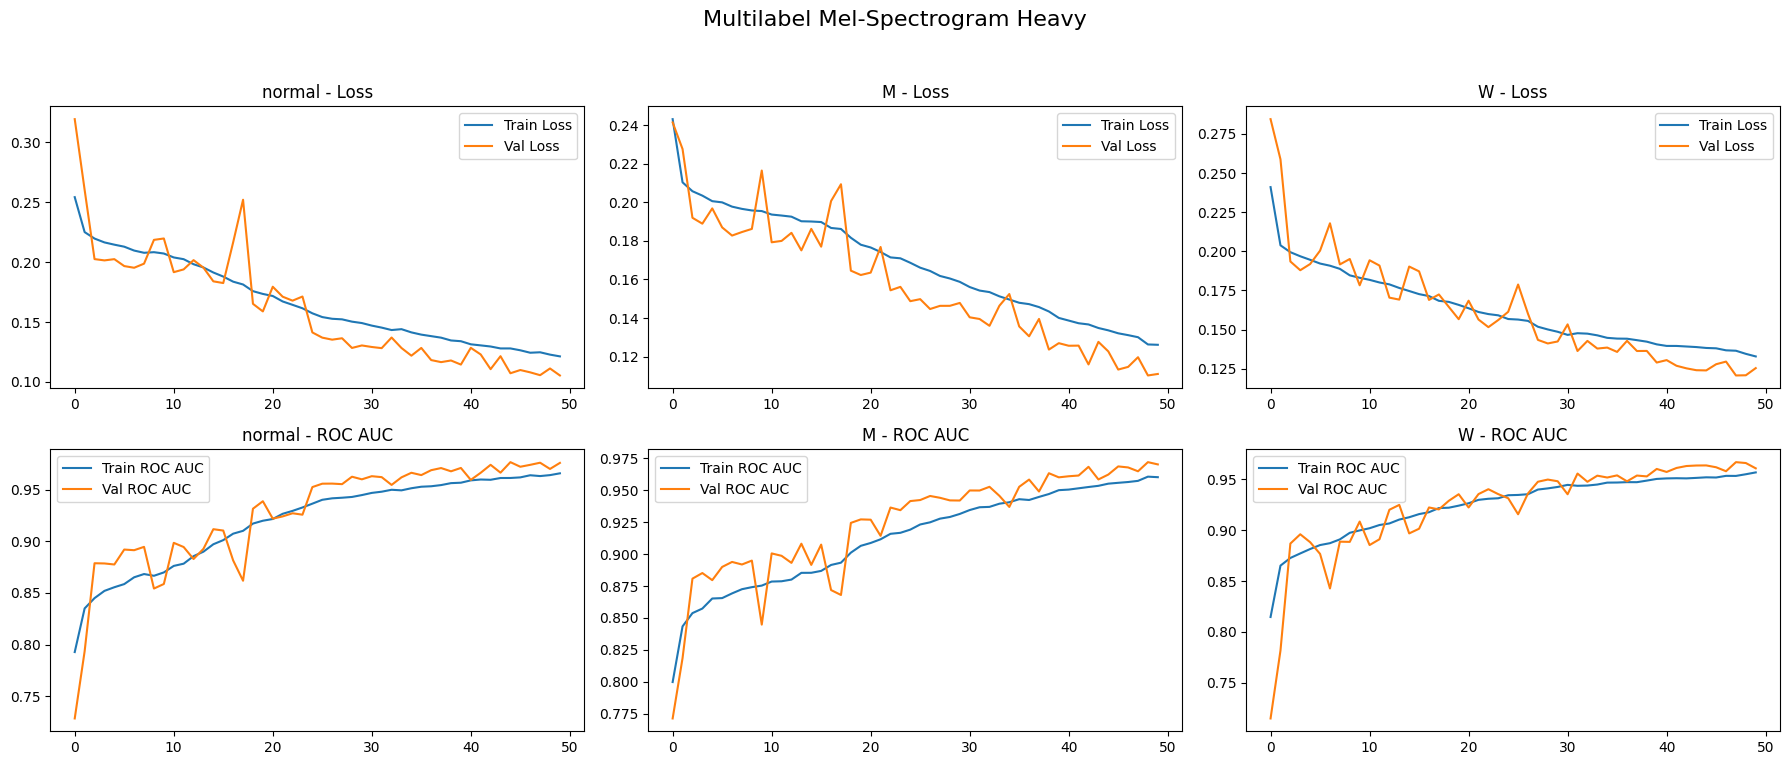

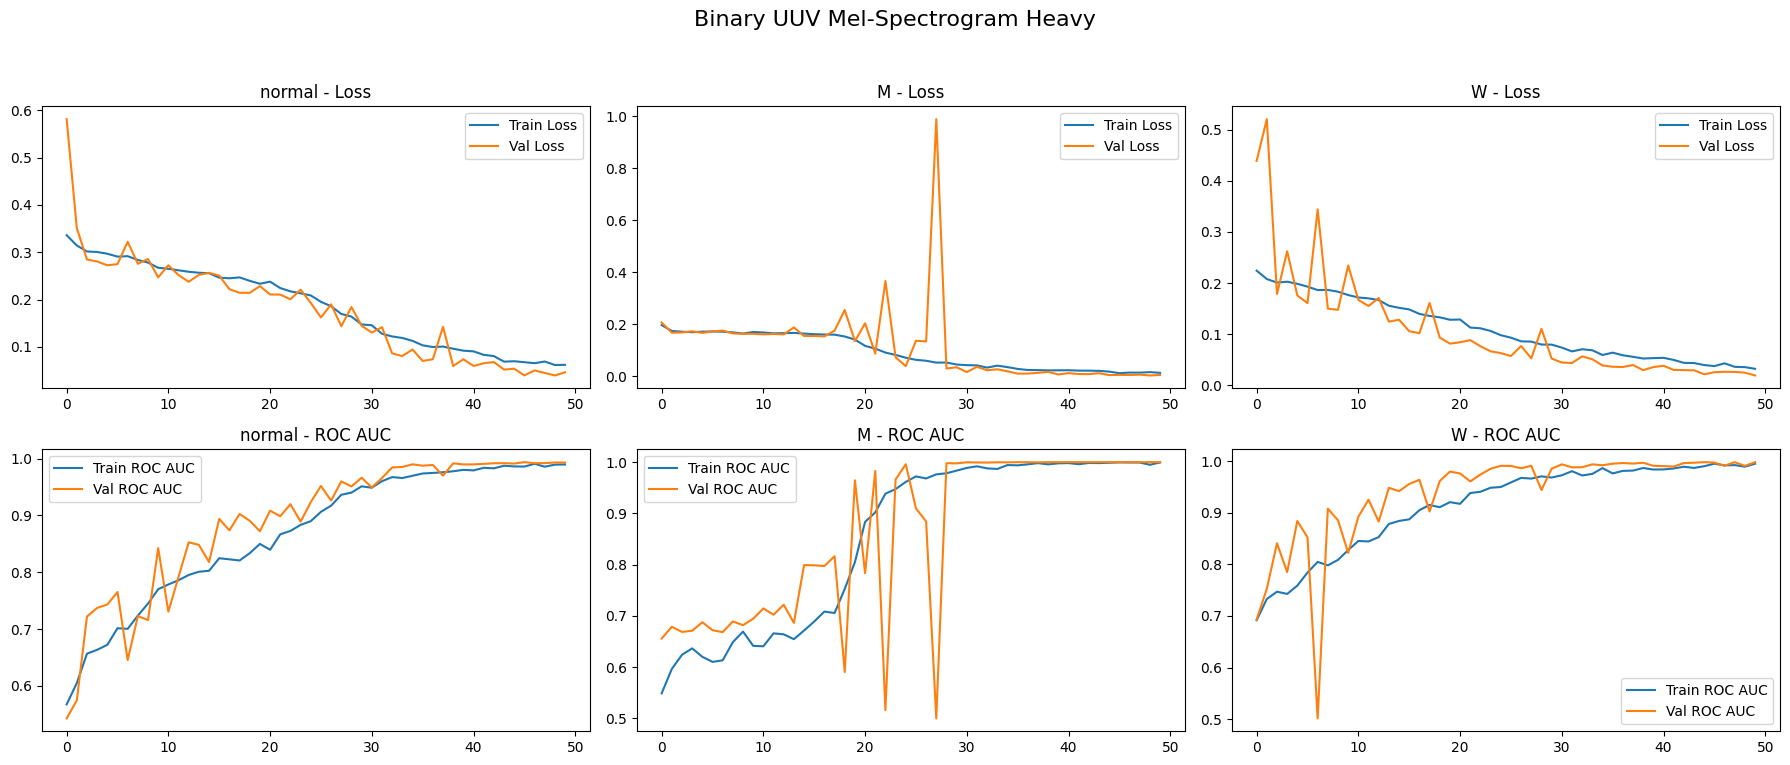

In [10]:
plot_training_histories(multilabel_histories, f"Multilabel {DATASET_LABEL}")
plot_training_histories(binary_histories, f"Binary UUV {DATASET_LABEL}")


## Save Artifacts

In [14]:
save_dir = save_keras_artifacts(
    save_dir="saved_artifacts",
    dataset_key=DATASET_KEY,
    multilabel_models=multilabel_models,
    binary_models=binary_models,
    multilabel_histories=multilabel_histories,
    binary_histories=binary_histories,
    multilabel_results=multilabel_results,
    binary_results=binary_results,
)
archive_path = zip_artifacts(save_dir, f"saved_models_and_results_{DATASET_KEY}.zip")
files.download(str(archive_path))

print(f"Saved artifacts to: {archive_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved artifacts to: /content/saved_models_and_results_heavy.zip


In [20]:
files.download(str(archive_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>